# Advanced Sentiment Analysis System

This notebook implements an advanced sentiment analysis pipeline using PyTorch, featuring:
1. **BiLSTM with Attention Mechanism**
2. **BERT (Transformer) Fine-tuning**
3. **Comprehensive EDA and Visualization**

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv


In [3]:
# 1. Environment Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
import time
import random

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Data Loading & EDA
We load the Sentiment140 dataset and perform exploratory data analysis.

In [4]:
import os

print("GPU:", torch.cuda.is_available())
print("Files:", os.listdir('/kaggle/input'))

GPU: True
Files: ['datasets']


In [5]:
DATA_PATH = DATA_PATH = '/kaggle/input/datasets/kazanova/sentiment140/training.1600000.processed.noemoticon.csv'
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']

df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1', names=columns)
df = df[['text', 'target']]
df['target'] = df['target'].replace(4, 1)  # 0: Neg, 1: Pos

# Downsample for speed in this demonstration
SAMPLE_SIZE = 1000000
df = pd.concat([
    df[df['target'] == 0].sample(SAMPLE_SIZE // 2, random_state=SEED),
    df[df['target'] == 1].sample(SAMPLE_SIZE // 2, random_state=SEED)
]).sample(frac=1).reset_index(drop=True)

print(df['target'].value_counts())
df.head()

target
1    500000
0    500000
Name: count, dtype: int64


,text,target
0,im losing my twitter v-card,1
1,5hours sleep... thank you! in the office now,0
2,"gonna write down all these questions now, and ...",1
3,had an amazing time yeserday except i have a r...,1
4,@kelseyhelzer just got out of the hot tub. Mis...,0


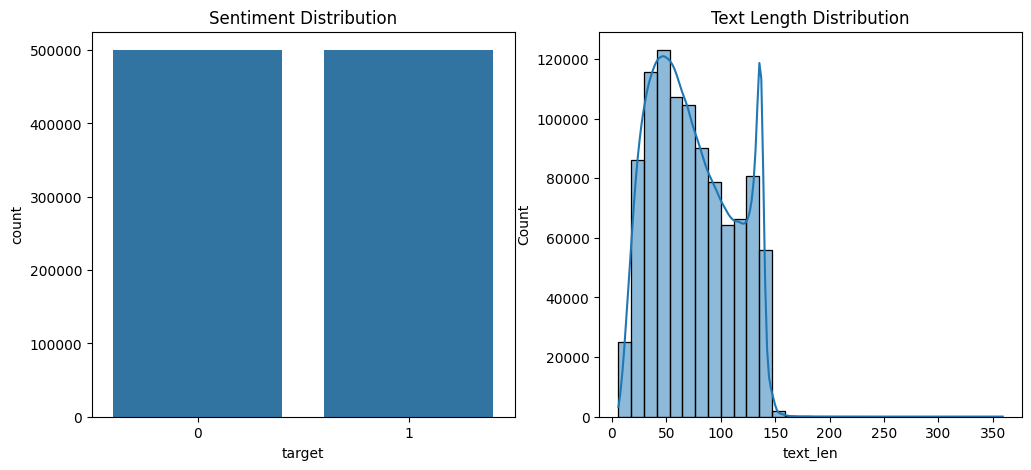

In [6]:
# EDA Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df)
plt.title('Sentiment Distribution')

df['text_len'] = df['text'].apply(len)
plt.subplot(1, 2, 2)
sns.histplot(df['text_len'], bins=30, kde=True)
plt.title('Text Length Distribution')
plt.show()

## 3. Text Preprocessing
Cleaning text and preparing it for models.

In [7]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text

df['cleaned_text'] = df['text'].apply(clean_text)
df.head()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,target,text_len,cleaned_text
0,im losing my twitter v-card,1,29,im losing twitter vcard
1,5hours sleep... thank you! in the office now,0,45,hours sleep thank office
2,"gonna write down all these questions now, and ...",1,102,gonna write questions ill make answer video to...
3,had an amazing time yeserday except i have a r...,1,122,amazing time yeserday except rash legs stomach...
4,@kelseyhelzer just got out of the hot tub. Mis...,0,58,got hot tub missin girl


## 4. Feature Engineering & BiLSTM Model
Implementing BiLSTM with an Attention mechanism.

In [8]:
from torch.nn.utils.rnn import pad_sequence

# Vocabulary
all_words = ' '.join(df['cleaned_text']).split()
vocab = {word: i+2 for i, (word, count) in enumerate(Counter(all_words).most_common(5000))}
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

def text_to_seq(text):
    return [vocab.get(word, 1) for word in text.split()]

MAX_LEN = 40
X_seq = [torch.tensor(text_to_seq(t)[:MAX_LEN]) for t in df['cleaned_text']]
X_pad = pad_sequence(X_seq, batch_first=True, padding_value=0)
y = torch.tensor(df['target'].values)

X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=SEED)

In [9]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, 1)
    def forward(self, output):
        weights = torch.softmax(self.attn(output), dim=1)
        context = torch.sum(weights * output, dim=1)
        return context, weights

class BiLSTMAttn(nn.Module):
    def __init__(self, vocab_sz, emb_dim, hid_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hid_dim, bidirectional=True, batch_first=True)
        self.attn = Attention(hid_dim)
        self.fc = nn.Linear(hid_dim * 2, 1)
    def forward(self, x):
        x = self.emb(x)
        out, _ = self.lstm(x)
        ctx, weights = self.attn(out)
        return self.fc(ctx), weights

model_bi = BiLSTMAttn(len(vocab), 100, 128).to(device)
optimizer = optim.Adam(model_bi.parameters())
criterion = nn.BCEWithLogitsLoss()

## 5. BERT Model Fine-tuning
Using Pretrained BERT for sequence classification.

In [10]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class BertSentiment(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = nn.Dropout(0.3)
        self.out = nn.Linear(self.bert.config.hidden_size, 2)
    def forward(self, ids, mask):
        _, pooled = self.bert(ids, attention_mask=mask, return_dict=False)
        return self.out(self.drop(pooled))

model_bert = BertSentiment().to(device)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 6. Training & Evaluation
Training loops and performance metrics.

In [17]:
def train_model(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.float().to(device)
        optimizer.zero_grad()
        out, _ = model(x)
        loss = criterion(out.squeeze(), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# BiLSTM Training
train_loader = DataLoader(
    list(zip(X_train, y_train)),
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
for epoch in range(30):
    loss = train_model(model_bi, train_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}, Loss: {loss:.4f}')

Epoch 1, Loss: 0.2585
Epoch 2, Loss: 0.2484
Epoch 3, Loss: 0.2401
Epoch 4, Loss: 0.2332
Epoch 5, Loss: 0.2278
Epoch 6, Loss: 0.2224
Epoch 7, Loss: 0.2187
Epoch 8, Loss: 0.2157
Epoch 9, Loss: 0.2125
Epoch 10, Loss: 0.2095
Epoch 11, Loss: 0.2071
Epoch 12, Loss: 0.2055
Epoch 13, Loss: 0.2036
Epoch 14, Loss: 0.2032
Epoch 15, Loss: 0.2015
Epoch 16, Loss: 0.2007
Epoch 17, Loss: 0.1995
Epoch 18, Loss: 0.1988
Epoch 19, Loss: 0.1982
Epoch 20, Loss: 0.1968
Epoch 21, Loss: 0.1971
Epoch 22, Loss: 0.1966
Epoch 23, Loss: 0.1965
Epoch 24, Loss: 0.1964
Epoch 25, Loss: 0.1964
Epoch 26, Loss: 0.1960
Epoch 27, Loss: 0.1946
Epoch 28, Loss: 0.1949
Epoch 29, Loss: 0.1954
Epoch 30, Loss: 0.1947


              precision    recall  f1-score   support

           0       0.76      0.74      0.75     99999
           1       0.74      0.77      0.76    100001

    accuracy                           0.75    200000
   macro avg       0.75      0.75      0.75    200000
weighted avg       0.75      0.75      0.75    200000



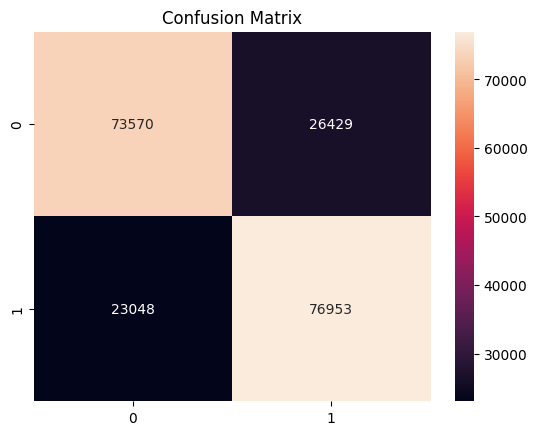

In [18]:
# Evaluation
test_loader = DataLoader(
    list(zip(X_test, y_test)),
    batch_size=64,   # keep small
    shuffle=False
)

model_bi.eval()
all_preds = []

with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(device)
        preds, _ = model_bi(x_batch)
        preds = torch.sigmoid(preds)
        all_preds.extend((preds > 0.5).int().cpu().numpy())

y_pred = np.array(all_preds)
    
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

## 7. Explainability & Visualization
Visualizing Attention weights.

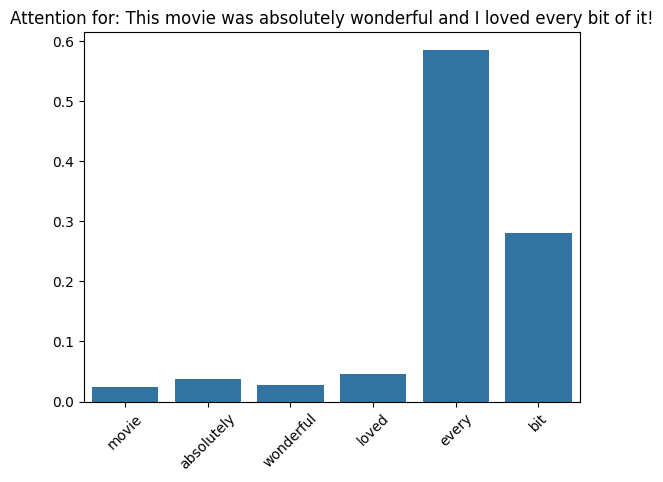

In [19]:
def explain_prediction(text):
    model_bi.eval()
    clean = clean_text(text)
    seq = torch.tensor(text_to_seq(clean)).unsqueeze(0).to(device)
    with torch.no_grad():
        out, weights = model_bi(seq)
    
    weights = weights.squeeze().cpu().numpy()
    words = clean.split()
    sns.barplot(x=words, y=weights[:len(words)])
    plt.title(f'Attention for: {text}')
    plt.xticks(rotation=45)
    plt.show()

explain_prediction('This movie was absolutely wonderful and I loved every bit of it!')

## 8. Model Saving
Saving weights and configurations.

In [20]:
SAVE_PATH = '/kaggle/working/bilstm_model_full.pth'

torch.save({
    'model_state_dict': model_bi.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'vocab': vocab,
    'max_len': MAX_LEN
}, SAVE_PATH)

print(f"Model saved at {SAVE_PATH}")

Model saved at /kaggle/working/bilstm_model_full.pth


In [21]:
BERT_SAVE_PATH = '/kaggle/working/bert_model'

model_bert.bert.save_pretrained(BERT_SAVE_PATH)
tokenizer.save_pretrained(BERT_SAVE_PATH)

print("BERT model saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT model saved!


In [16]:
plt.savefig('/kaggle/working/confusion_matrix.png')

<Figure size 640x480 with 0 Axes>